# Imports

In [1]:
from typing import Iterator

import scipy
import duckdb
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm, trange

# Plots
import seaborn as sns
import matplotlib.pyplot as plt

# Modelos
import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.utils.data import TensorDataset, DataLoader

import kennard_stone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, minmax_scale
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_validate,
)
from sklearn.metrics import (
    make_scorer,
    r2_score,
    root_mean_squared_error,
    mean_squared_error,
    mean_absolute_error,
)

from sklearn.linear_model import BayesianRidge
# from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from tabpfn import TabPFNRegressor
from tabpfn.constants import ModelVersion
from cubist import Cubist
# from synthefy_nori import NoriRegressor

# from arfs.feature_selection.allrelevant import Leshy
# from sklearn.feature_selection import (
#     SelectKBest,
#     SelectFromModel,
#     mutual_info_regression,
#     f_regression
# )
# from feature_engine.selection import (
#     MRMR,
#     SelectByShuffling,
# )

from sklearn.ensemble import RandomForestRegressor, RandomTreesEmbedding
from sklearn.kernel_approximation import RBFSampler
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import (
    PCA,
    NMF,
    FactorAnalysis,
    DictionaryLearning,
    FastICA,
)


from custom_models import (
    rpiq,
    plot_metrics,
    OptimizedPLS,
    PoissonScaler,
    DeepRegressor,
    AutoFactorAnalysis,
)

import warnings
warnings.simplefilter('ignore', UserWarning)

import logging
logging.getLogger('kennard_stone').setLevel(logging.WARNING)

# Carrega os dados

In [2]:
df_xrf = duckdb.read_csv('XRF_library.csv').df()
df_xrf.drop(columns=['year', 'sample'], inplace=True)
df_xrf.set_index('Area', inplace=True)
df_xrf.sort_index(inplace=True)

df_xrf.sample(10, random_state=0).style.format(precision=2)

## Define os targets e as features

In [3]:
targets = ['SOC', 'exCa', 'exMg', 'exK', 'SB']
features = [
    col
    for col in df_xrf.columns
    if col not in {*targets, 'SOC', 'pH', 'H+Al', 'Pav', 'CEC'}
]

print('features:', [*features[:3], '...', *features[-3:]])

features: ['1', '1.02', '1.04', '...', '14.96', '14.98', '15']


In [4]:
X = df_xrf[features]
y = df_xrf[targets[0]].to_numpy()

## Método de validação cruzada

Foram testados 3 métodos de validação cruzada (K-Fold):
1. Simples
2. Estratificado
3. Kennard-Stone

Não foi encontrado diferença significativa entre os métodos.
<br>
O estratificado se saiu um pouco melhor no geral que os outros.
<br>
A escolha do Kennard-Stone foi para manter coerencia com o artigo inicial.

In [5]:
def print_separacao_splits(
    cv_split: tuple,
    X: pd.DataFrame,
) -> None:
    """
    Imprime a contagem dos rótulos do índice de X nos conjuntos de
    treino e teste de cada fold da validação cruzada, além do total geral.
    """
    print('#  ', X.index.value_counts().to_dict())
    for fold, (train_index, test_index) in enumerate(cv_split, start=1):
        counter_train = X.iloc[train_index].index.value_counts().to_dict()
        counter_test = X.iloc[test_index].index.value_counts().to_dict()
        counter_train = X.iloc[train_index].index.value_counts().to_dict()
        counter_test = X.iloc[test_index].index.value_counts().to_dict()
        print(f'{fold:<3}', counter_train, counter_test)

In [6]:
# split_simples = tuple(KFold(n_splits=10, shuffle=True, random_state=0).split(X))
# split_estratificado = tuple(StratifiedKFold(n_splits=10, shuffle=True, random_state=0).split(X, X.index))
split_kennard_stone = tuple(kennard_stone.KFold(n_splits=10).split(minmax_scale(X)))

print_separacao_splits(split_kennard_stone, X)

#   {'Cambe': 614, 'Toledo': 354}
1   {'Cambe': 552, 'Toledo': 319} {'Cambe': 62, 'Toledo': 35}
2   {'Cambe': 554, 'Toledo': 317} {'Cambe': 60, 'Toledo': 37}
3   {'Cambe': 551, 'Toledo': 320} {'Cambe': 63, 'Toledo': 34}
4   {'Cambe': 552, 'Toledo': 319} {'Cambe': 62, 'Toledo': 35}
5   {'Cambe': 555, 'Toledo': 316} {'Cambe': 59, 'Toledo': 38}
6   {'Cambe': 554, 'Toledo': 317} {'Cambe': 60, 'Toledo': 37}
7   {'Cambe': 555, 'Toledo': 316} {'Cambe': 59, 'Toledo': 38}
8   {'Cambe': 548, 'Toledo': 323} {'Cambe': 66, 'Toledo': 31}
9   {'Cambe': 554, 'Toledo': 318} {'Cambe': 60, 'Toledo': 36}
10  {'Cambe': 551, 'Toledo': 321} {'Cambe': 63, 'Toledo': 33}


## OptimizedPLS

Para reproduzir a seleção do número de componentes do PLS, a classe OptimizedPLS foi criada, de acordo com o artigo:

* "*To properly select the number of latent variables (LV) cross-validation using contiguous blocks with 10 splits was applied.*"
* "*The number of LV was chosen according to the minimum root mean square error of cross-validation (RMSECV).*"

## PoissonScaler

$\lambda = \mu = \sigma²$

$\sigma = \sqrt{\mu}$

$X' = \frac{X}{\sqrt{\bar{X}}}$

$X_\text{scaled} = X' - \bar{X'}$

## Modelos Lineares

Tentei reproduzir o máximo que pude do artigo para definir os baselines, modelos baseados em PLS.

### 1. OptimizedPLS
Para reproduzir a seleção do número de componentes do PLS, a classe OptimizedPLS foi criada, de acordo com o artigo:

* "*To properly select the number of latent variables (LV) cross-validation using contiguous blocks with 10 splits was applied.*"
* "*The number of LV was chosen according to the minimum root mean square error of cross-validation (RMSECV).*"


### 2. PoissonScaler + OptimizedPLS
Mesmo modelo anterior, mas com pré processamento dividindo cada feature pela raiz quadrada de sua média:

$$\lambda = \mu = \sigma²$$

$$\sigma = \sqrt{\mu}$$

$$X' = \frac{X}{\sqrt{\bar{X}}}$$

$$X_\text{scaled} = X' - \bar{X'}$$


### 3. BayesianRidge
Uma regressão linear bayesiana com regularização:
* Considera incertezas na previsão, estimando a média condicional e a variância.
* Utiliza priors gaussianos centrados em zero, o que introduz uma regularização L2 automática e evita valores extremos nos coeficientes.
* Os coeficientes tendem a ser mais conservadores (contraídos em direção a zero), reduzindo a variância e prevenindo overfitting, especialmente em dados de alta dimensionalidade ou com multicolinearidade.
* Teoricamente, a abordagem bayesiana é robusta para conjuntos de dados pequenos, pois os priors atuam como informação adicional. Ela é relacionada a estimadores de encolhimento, como o estimador James-Stein, embora não seja idêntica a ele.
* Os hiperparâmetros (alpha e lambda) são estimados automaticamente a partir dos dados por maximização da evidência, o que dispensa uma busca manual exaustiva como a que seria necessária em validação cruzada para o OptimizedPLS.


### 4. FactorAnalysis

- Aplica análise fatorial para agrupar features que "se movem juntas" em fatores comuns, reduzindo a dimensionalidade.
- Os fatores resultantes são ortogonais entre si (não correlacionados), o que elimina o problema de multicolinearidade **entre os fatores** — as features originais ainda podem ser correlacionadas.
- Cada fator carrega informação única não redundante.
- A matriz de correlação foi estimada com Oracle Approximating Shrinkage (OAS) após padronização das features, o que torna a estimativa mais robusta em cenários com poucas amostras ou alta dimensionalidade.
- A classe implementada suporta quatro critérios de seleção automática do número de fatores, todos não supervisionados (não usam validação cruzada):
  - `'kc'` — **Kaiser Criterion**<sup>[1](#ref1)</sup>: mantém fatores com autovalores ≥ 1 (critério padrão).
  - `'ekc'` — **Empirical Kaiser Criterion**<sup>[2](#ref2)</sup>: versão corrigida que compara os autovalores com um valor de referência empírico que depende de `n` e `p`.
  - `'pa'` — **Parallel Analysis**<sup>[3](#ref3)</sup>: compara os autovalores observados com os obtidos de dados aleatórios (percentil 95), retendo apenas os que os superam.
  - `'map'` — **Velicer's Minimum Average Partial (MAP)**<sup>[4](#ref4)</sup>: escolhe o número de fatores que minimiza a média das correlações parciais quadráticas.

Na minha opinião, a Análise Fatorial pode reduzir melhor as features, pois as "clusteriza" e não depende de validação cruzada na seleção, como no caso do PLS.

### 5. Foundation Models
Além dos modelos clássicos, foram avaliados modelos de fundação<sup>[5](#ref5), [6](#ref6)</sup>, que são redes neurais Transformer pré-treinadas em grandes volumes de dados sintéticos e que realizam aprendizado em contexto (in-context learning): basta fornecer o conjunto de treino e o modelo faz previsões sem qualquer ajuste de pesos.

- Não exigem seleção manual de hiperparâmetros nem de número de componentes, o que reduz o risco de overfitting induzido por validação cruzada mal especificada.
- Aprendem relações não lineares complexas entre features e target, capturando interações que modelos como PLS e BayesianRidge não conseguem representar.

O melhor modelo desse tipo considerado atualmente é o TabPFN<sup>[6](#ref6)</sup>, na versão 3.5 (15/09/2026). Mas a única versão que tem uma licença permissíva (Apache 2.0) é a versão TabPFN v2, as versões mais recentes do modelo possuem uma licença comercial específica. A v2 desse modelo tem restrição de número de features: 500, sendo necessário uma redução "obrigatória" do número de features.

---

#### Referências

<a id="ref1"></a>
[1] KAISER, H. F. The application of electronic computers to factor analysis. *Educational and Psychological Measurement*, v. 20, n. 1, p. 141–151, 1960. DOI: [10.1177/001316446002000116](https://sci-hub.box/10.1177/001316446002000116). 🗝️🐦

<a id="ref2"></a>
[2] BRAEKEN, J.; VAN ASSEN, M. A. L. M. An empirical Kaiser criterion. *Psychological Methods*, v. 22, n. 3, p. 450–466, 2017. DOI: [10.1037/met0000074](https://doi.org/10.1037/met0000074).

<a id="ref3"></a>
[3] HORN, J. L. A rationale and a test for the number of factors in factor analysis. *Psychometrika*, v. 30, n. 2, p. 179–185, 1965. DOI: [10.1007/BF02289447](https://sci-hub.box/10.1007/BF02289447). 🗝️🐦

<a id="ref4"></a>
[4] VELICER, W. F. Determining the number of components from the matrix of partial correlations. *Psychometrika*, v. 41, n. 3, p. 321–327, 1976. DOI: [10.1007/BF02293557](https://sci-hub.box/10.1007/BF02293557). 🗝️🐦

<a id="ref5"></a>
[5] RAIELI, S. et al. Escaping the forest: a sparse, interpretable, and foundational neural network alternative for tabular data. *npj Artificial Intelligence*, 2026. DOI: [10.1038/s44387-025-00056-0](https://doi.org/10.1038/s44387-025-00056-0).

<a id="ref6"></a>
[6] HOLLMANN, N. et al. Accurate predictions on small data with a tabular foundation model. *Nature*, v. 637, p. 319–326, 2025. DOI: [10.1038/s41586-024-08328-6](https://doi.org/10.1038/s41586-024-08328-6).

In [7]:
models = {
    'OptPLS': OptimizedPLS(max_lv=20, n_splits=10),
    # 'PS+OptPLS': Pipeline(steps=[
    #     ('scaler', PoissonScaler()),
    #     ('model', OptimizedPLS(max_lv=20, n_splits=10, scale=False)),
    # ]),
    # 'BR': BayesianRidge(),
    # 'SKB+BR': Pipeline(steps=[
    #     ('scaler', StandardScaler()),
    #     ('feature_selection', SelectKBest(score_func=mutual_info_regression, k=200)),
    #     ('model', BayesianRidge()),
    # ]),
    # 'MRMR+BR': Pipeline(steps=[
    #     ('scaler', StandardScaler()),
    #     ('feature_selection', MRMR(method='FCD', regression=True)),
    #     ('model', BayesianRidge()),
    # ]),
    # 'FA_BR': Pipeline(steps=[
    #     ('scaler', StandardScaler()),
    #     ('fa', AutoFactorAnalysis(method='kc', svd_method='lapack')),
    #     ('model', BayesianRidge()),
    # ]),

    # 'XGBoost': XGBRegressor(verbosity=0, n_jobs=-1),
    # 'LGBM': LGBMRegressor(verbose=-1, n_jobs=-1),
    # 'CatBoost': CatBoostRegressor(thread_count=-1, verbose=False),
    'Cubist': Cubist(n_committees=5, auto=True),

    'FA+TabPFN2.0': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('fa', AutoFactorAnalysis(method='map', svd_method='lapack')),
        ('model', TabPFNRegressor.create_default_for_version(ModelVersion.V2, device='cuda')),
    ]),
    'FA+TabPFN3.5': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('fa', AutoFactorAnalysis(method='map', svd_method='lapack')),
        ('model', TabPFNRegressor.create_default_for_version(ModelVersion.V3_5, device='cuda')),
    ]),

    # 'SFM_TabPFN': Pipeline(steps=[
    #     ('scaler', StandardScaler()),
    #     ('feature_selection', SelectFromModel(
    #         estimator=LGBMRegressor(
    #             n_estimators=500,
    #             importance_type='gain',
    #             verbose=-1,
    #             n_jobs=-1
    #         ),
    #         max_features=100
    #     )),
    #     ('model', TabPFNRegressor.create_default_for_version(ModelVersion.V2, device='cuda')),
    # ]),
    # 'FA_NoriRegressor': Pipeline(steps=[
    #     ('scaler', StandardScaler()),
    #     ('fa', AutoFactorAnalysis(method='map', svd_method='lapack')),
    #     ('model', NoriRegressor(model='nori-30m', device='cuda')),
    # ]),
    # 'NoriRegressor': NoriRegressor(device='cuda'),

    # 'PCA+TabPFN': Pipeline(steps=[
    #     ('scaler', StandardScaler()),
    #     ('pca', PCA(n_components=280)),
    #     ('model', TabPFNRegressor.create_default_for_version(ModelVersion.V2, device='cuda')),
    # ]),

    # 'FA+TabFM': Pipeline(steps=[
    #     ('scaler', StandardScaler()),
    #     ('fa', AutoFactorAnalysis(method='map', svd_method='lapack')),
    #     ('model', TabPFNRegressor.create_default_for_version(ModelVersion.V2, device='cuda')),
    # ]),

    # 'Leshy+TabPFN': Pipeline(steps=[
    #     ('leshy', Leshy(LGBMRegressor(verbose=-1))),
    #     ('model', TabPFNRegressor(device='cuda')),
    # ]),
    # 'FA23+TabPFN': Pipeline(steps=[
    #     ('pca', FactorAnalysis(n_components=23, max_iter=100_000)),
    #     ('model', TabPFNRegressor(device='cuda')),
    # ]),
    # 'FA59+TabPFN': Pipeline(steps=[
    #     ('pca', FactorAnalysis(n_components=59, max_iter=100_000)),
    #     ('model', TabPFNRegressor.create_default_for_version(ModelVersion.V2, device='cuda')),
    # ]),
    # 'FCD+TabPFN': Pipeline(steps=[
    #     ('pca', MRMR(method='FCD', regression=True)),
    #     ('model', TabPFNRegressor(device='cuda')),
    # ]),
}

In [8]:
def plot_results_models_challenge(split, df_xrf, features, targets):
    iterator_target = tqdm(targets, desc='Targets')
    for target in iterator_target:
        iterator_target.set_postfix({'target': target})
        rows = []
        iterator_model = tqdm(models.items(), desc='Models')
        for model_name, model in iterator_model:
            iterator_model.set_postfix({'model': model_name})
            iterator_cv = tqdm(
                split,
                total=len(split),
                desc=f'CV Splits for {model_name}',
            )

            for train_index, test_index in iterator_cv:
                X_train = df_xrf[features].iloc[train_index]
                X_test = df_xrf[features].iloc[test_index]
                y_train = df_xrf[target].iloc[train_index]
                y_test = df_xrf[target].iloc[test_index]

                model.fit(X_train, y_train)

                y_fitted = model.predict(X_train)
                y_pred = model.predict(X_test)

                rows.extend(
                    (model_name, metric, value)
                    for metric, value in {
                        'R2[train]': r2_score(y_train, y_fitted),
                        'R2[test]': r2_score(y_test, y_pred),
                        'RMSE[train]': root_mean_squared_error(y_train, y_fitted),
                        'RMSE[test]': root_mean_squared_error(y_test, y_pred),
                        'RPIQ[train]': rpiq(y_train, y_fitted),
                        'RPIQ[test]': rpiq(y_test, y_pred),
                    }.items()
                )

        df_scores = pd.DataFrame(rows, columns=['model', 'metric', 'value'])
        plot_metrics(df_scores, target)

Targets:   0%|          | 0/5 [00:00<?, ?it/s]

Models:   0%|          | 0/4 [00:00<?, ?it/s]

CV Splits for OptPLS:   0%|          | 0/10 [00:00<?, ?it/s]

CV Splits for Cubist:   0%|          | 0/10 [00:00<?, ?it/s]

CV Splits for FA+TabPFN2.0:   0%|          | 0/10 [00:00<?, ?it/s]

CV Splits for FA+TabPFN3.5:   0%|          | 0/10 [00:00<?, ?it/s]

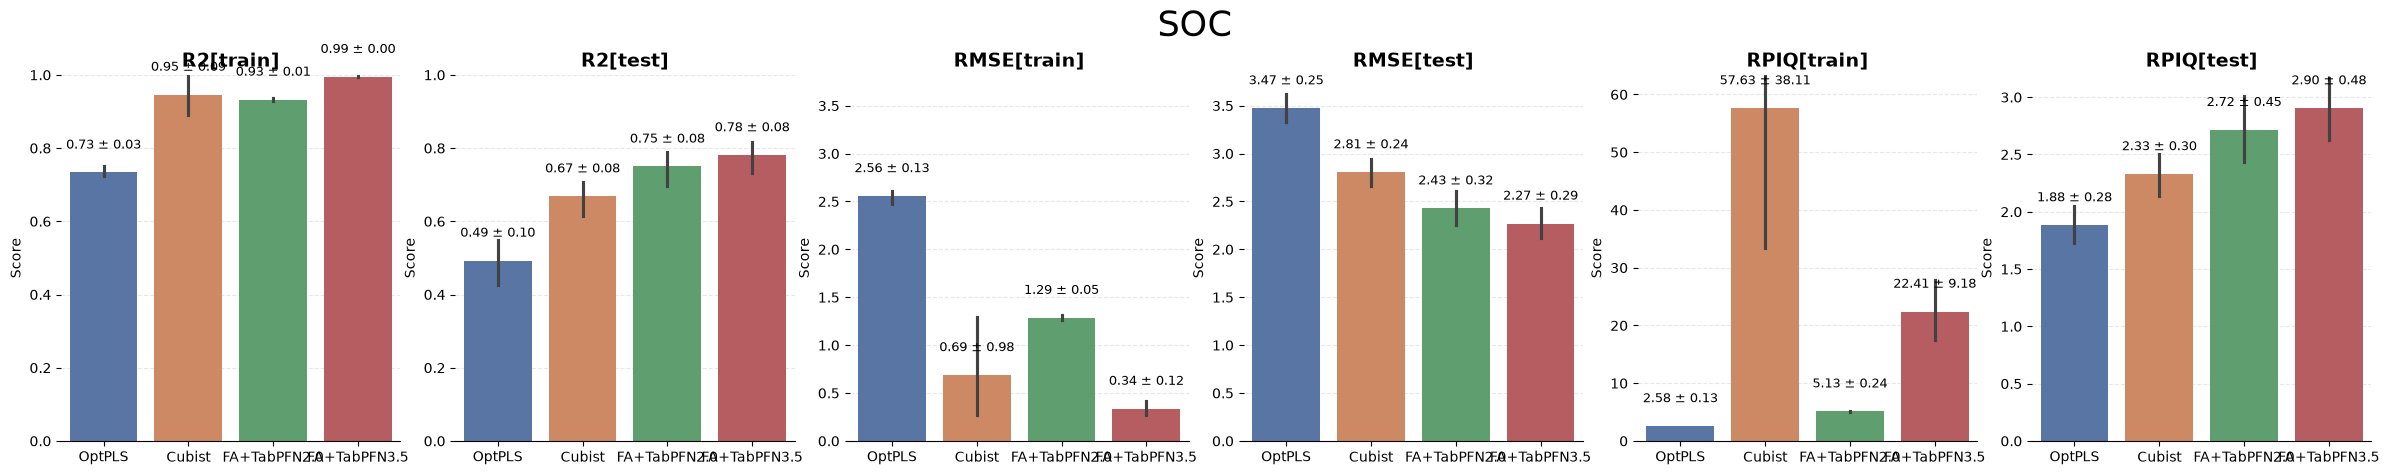

Models:   0%|          | 0/4 [00:00<?, ?it/s]

CV Splits for OptPLS:   0%|          | 0/10 [00:00<?, ?it/s]

CV Splits for Cubist:   0%|          | 0/10 [00:00<?, ?it/s]

CV Splits for FA+TabPFN2.0:   0%|          | 0/10 [00:00<?, ?it/s]

CV Splits for FA+TabPFN3.5:   0%|          | 0/10 [00:00<?, ?it/s]

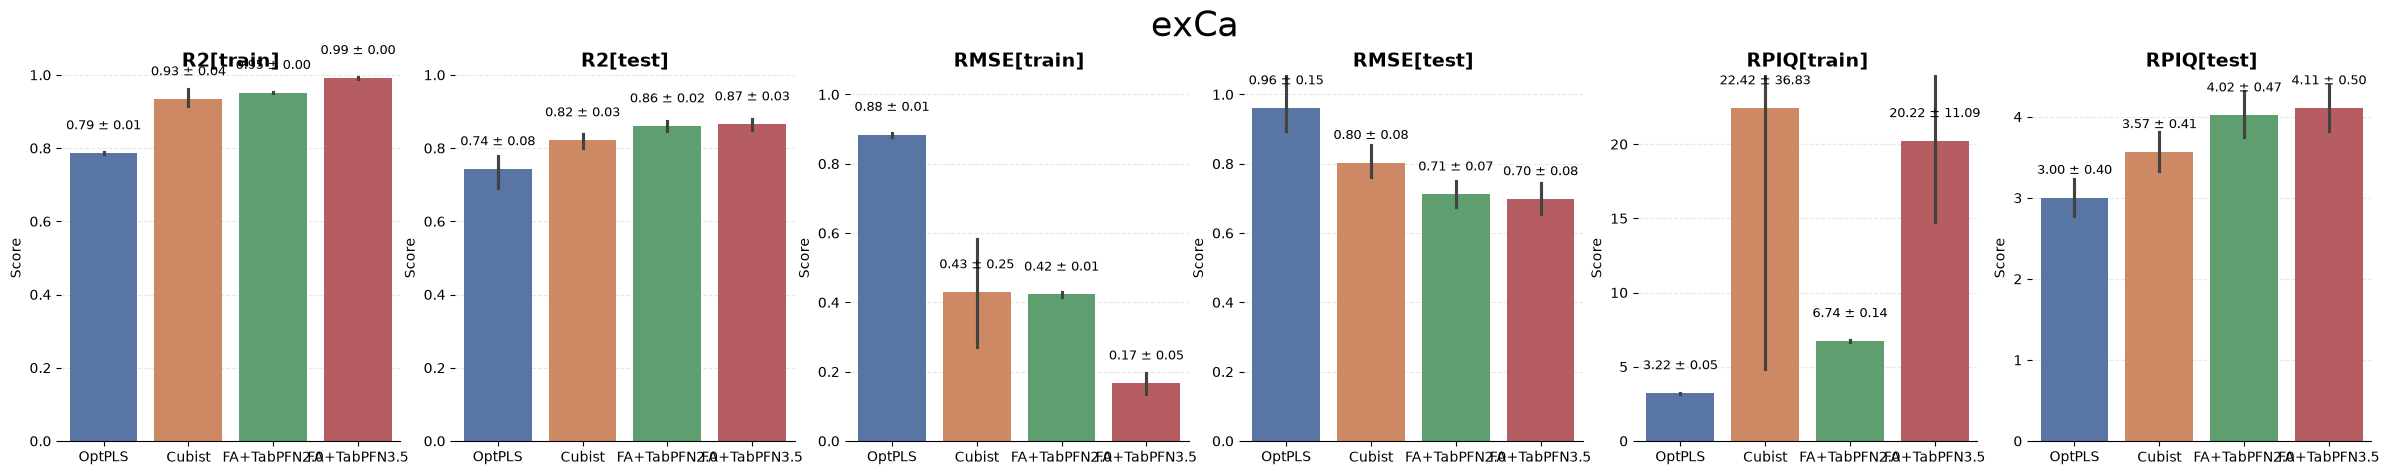

Models:   0%|          | 0/4 [00:00<?, ?it/s]

CV Splits for OptPLS:   0%|          | 0/10 [00:00<?, ?it/s]

CV Splits for Cubist:   0%|          | 0/10 [00:00<?, ?it/s]

CV Splits for FA+TabPFN2.0:   0%|          | 0/10 [00:00<?, ?it/s]

CV Splits for FA+TabPFN3.5:   0%|          | 0/10 [00:00<?, ?it/s]

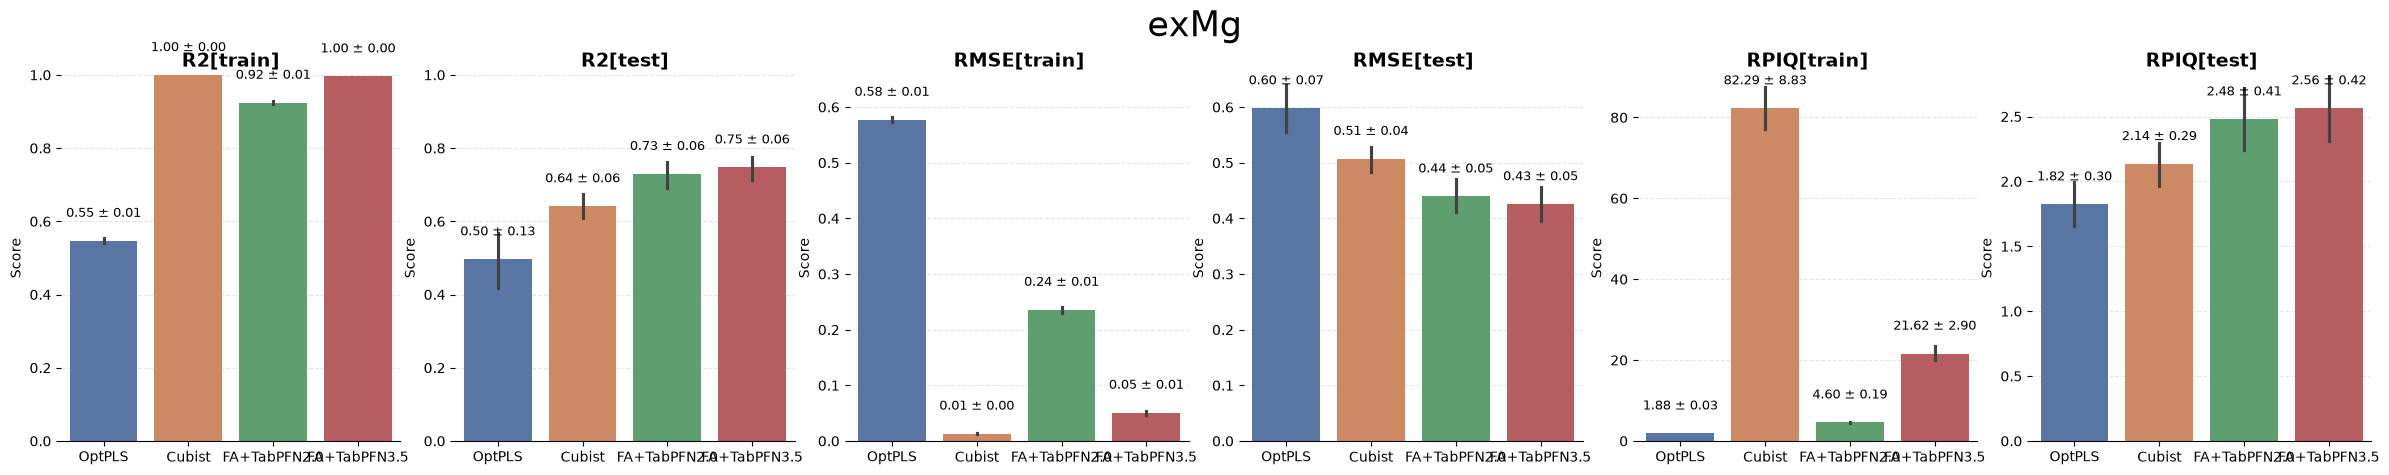

Models:   0%|          | 0/4 [00:00<?, ?it/s]

CV Splits for OptPLS:   0%|          | 0/10 [00:00<?, ?it/s]

CV Splits for Cubist:   0%|          | 0/10 [00:00<?, ?it/s]

CV Splits for FA+TabPFN2.0:   0%|          | 0/10 [00:00<?, ?it/s]

CV Splits for FA+TabPFN3.5:   0%|          | 0/10 [00:00<?, ?it/s]

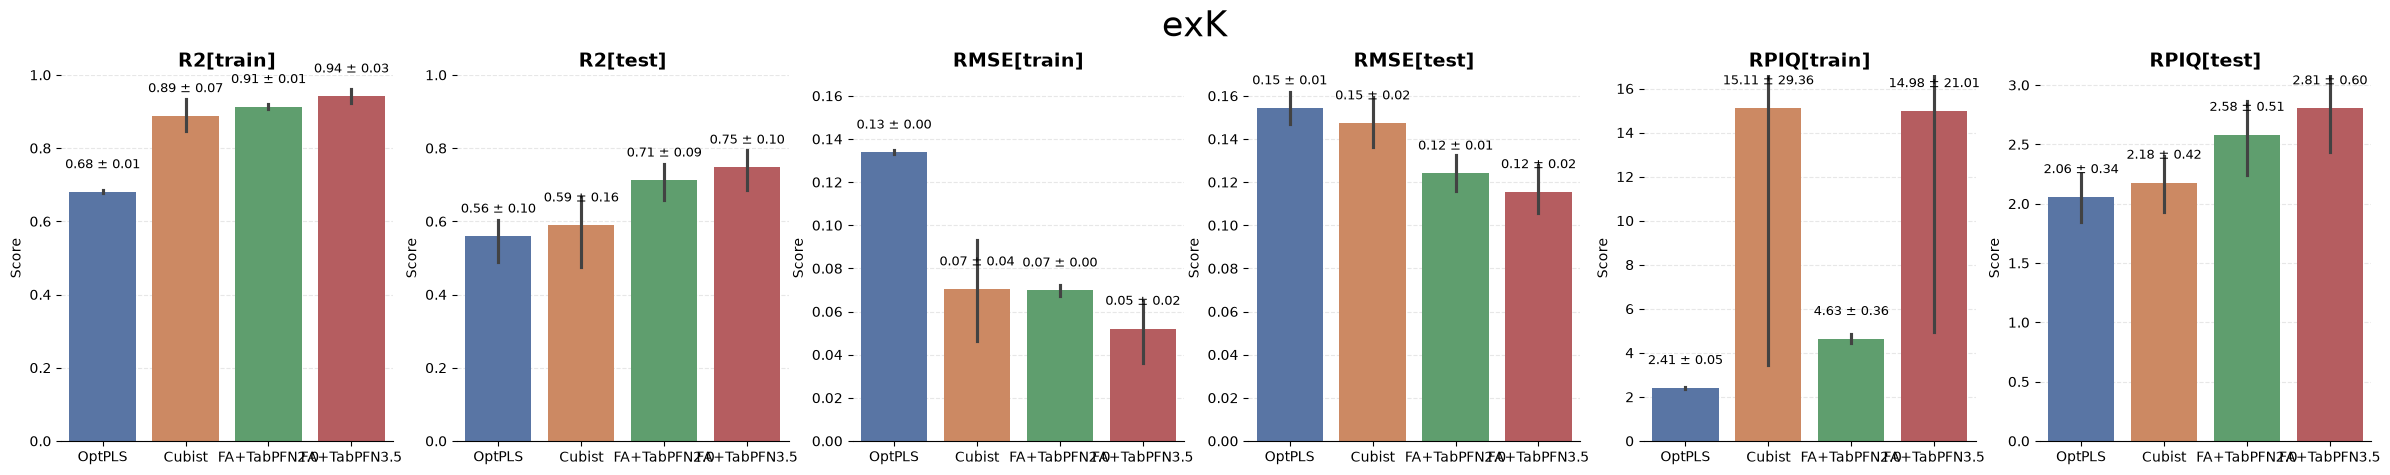

Models:   0%|          | 0/4 [00:00<?, ?it/s]

CV Splits for OptPLS:   0%|          | 0/10 [00:00<?, ?it/s]

CV Splits for Cubist:   0%|          | 0/10 [00:00<?, ?it/s]

CV Splits for FA+TabPFN2.0:   0%|          | 0/10 [00:00<?, ?it/s]

CV Splits for FA+TabPFN3.5:   0%|          | 0/10 [00:00<?, ?it/s]

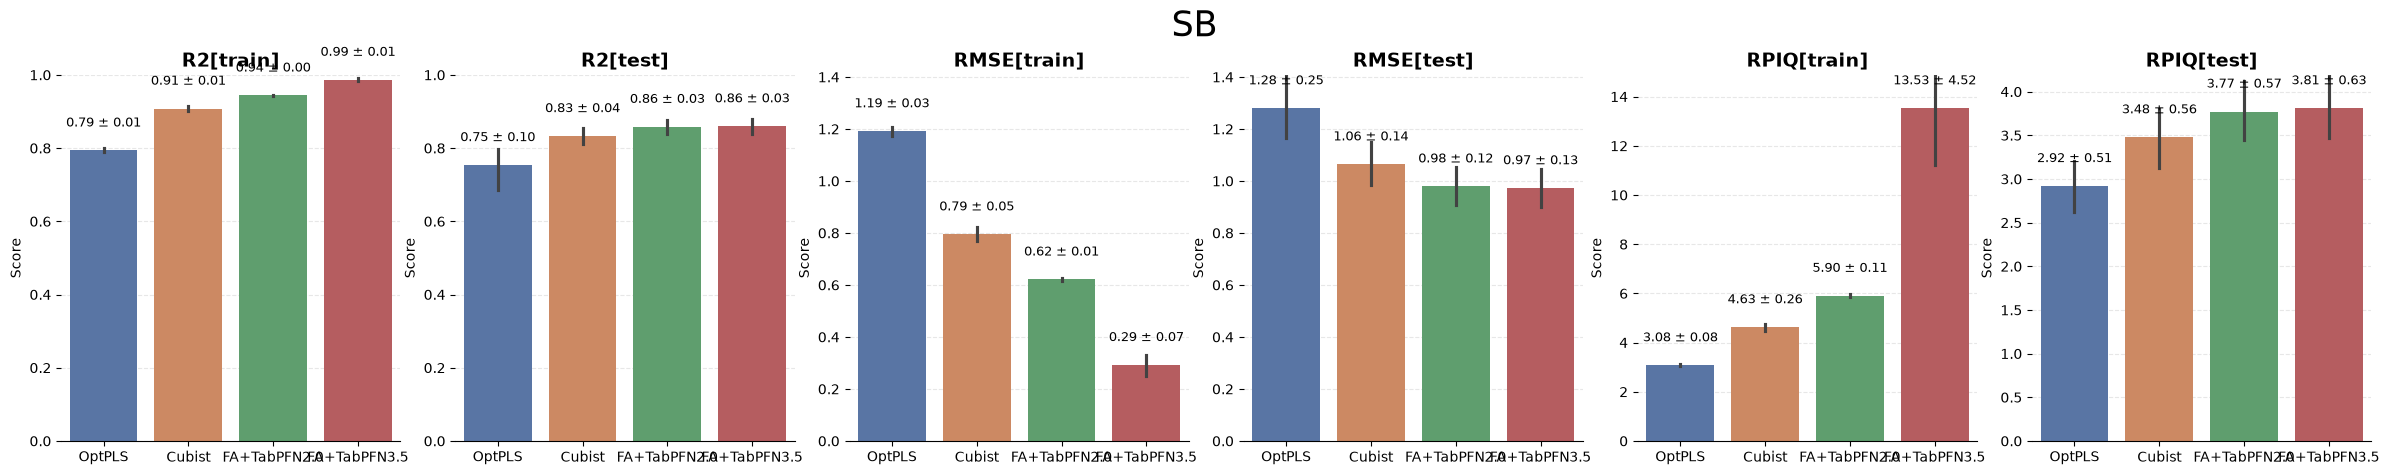

In [10]:
plot_results_models_challenge(split_kennard_stone, df_xrf, features, targets)